In [2]:
import pandas as pd
import numpy as np

In [3]:
yield_df = pd.read_csv(r"C:\Users\Shiva Teja\Downloads\archive (9)\crop_yield.csv")

In [4]:
# ==========================================
# TARGET & FEATURE ANALYSIS
# ==========================================

target = "Yield"

features = [
    "Crop",
    "Crop_Year",
    "Season",
    "State",
    "Area",
    "Production",
    "Annual_Rainfall",
    "Fertilizer",
    "Pesticide"
]

print("Target:", target)
print("\nFeatures:")
print(features)

print("\nTarget Statistics:")
print(yield_df[target].describe())

Target: Yield

Features:
['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide']

Target Statistics:
count    19689.000000
mean        79.954009
std        878.306193
min          0.000000
25%          0.600000
50%          1.030000
75%          2.388889
max      21105.000000
Name: Yield, dtype: float64


In [5]:
# Check correlation with Yield

numeric_cols = [
    "Crop_Year",
    "Area",
    "Production",
    "Annual_Rainfall",
    "Fertilizer",
    "Pesticide",
    "Yield"
]

correlation = yield_df[numeric_cols].corr()["Yield"].sort_values(
    ascending=False
)

print(correlation)

Yield              1.000000
Production         0.570809
Annual_Rainfall    0.020761
Fertilizer         0.002862
Crop_Year          0.002539
Area               0.001858
Pesticide          0.001782
Name: Yield, dtype: float64


In [6]:
features = [
    "Crop",
    "Crop_Year",
    "Season",
    "State",
    "Area",
    "Annual_Rainfall",
    "Fertilizer",
    "Pesticide"
]

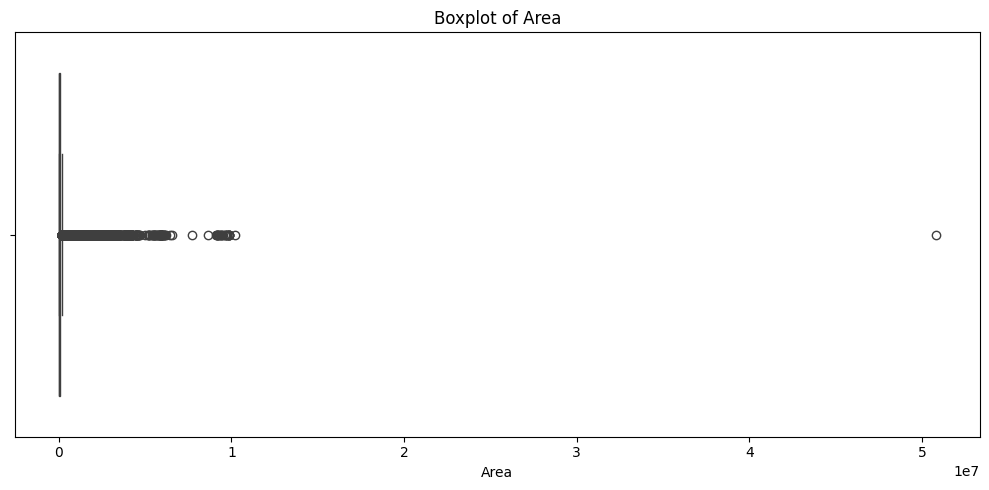

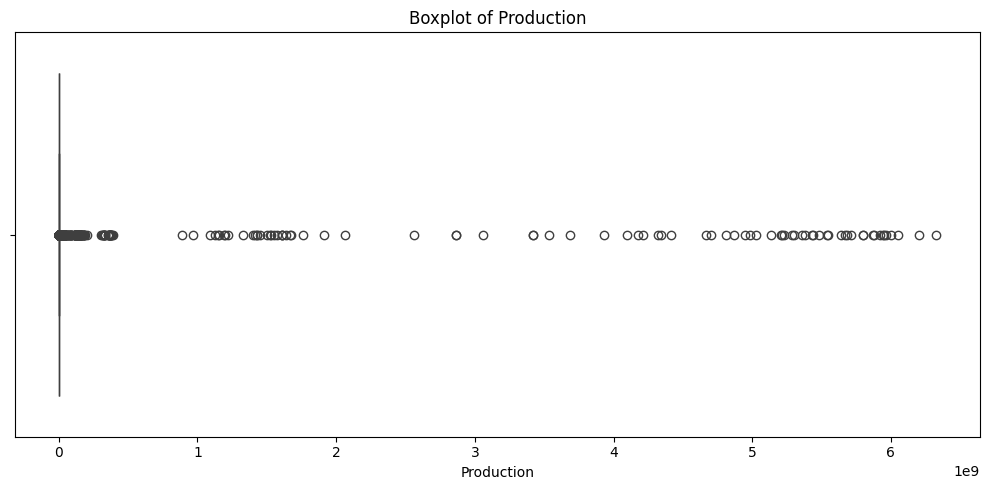

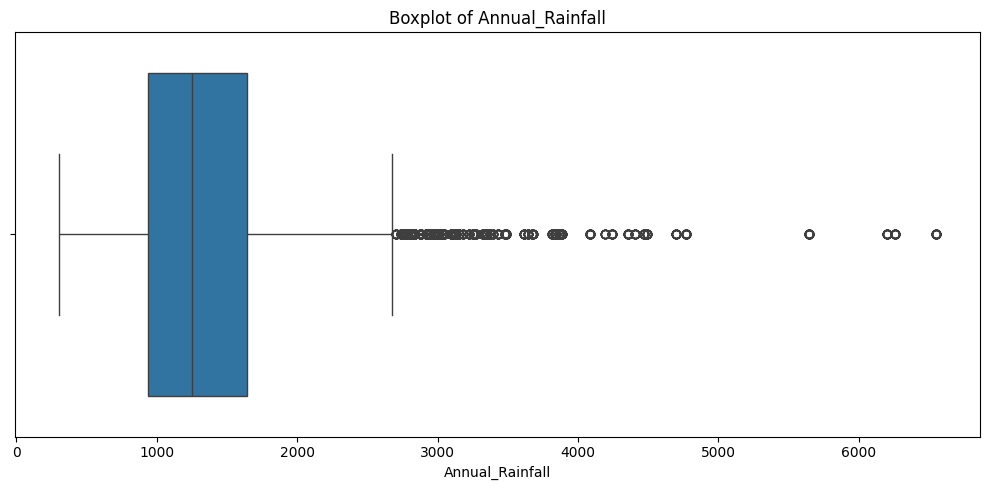

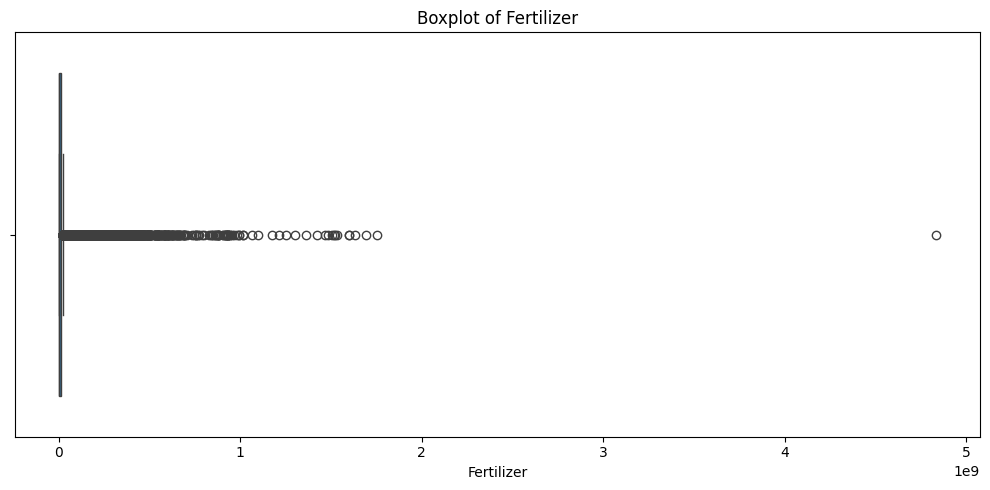

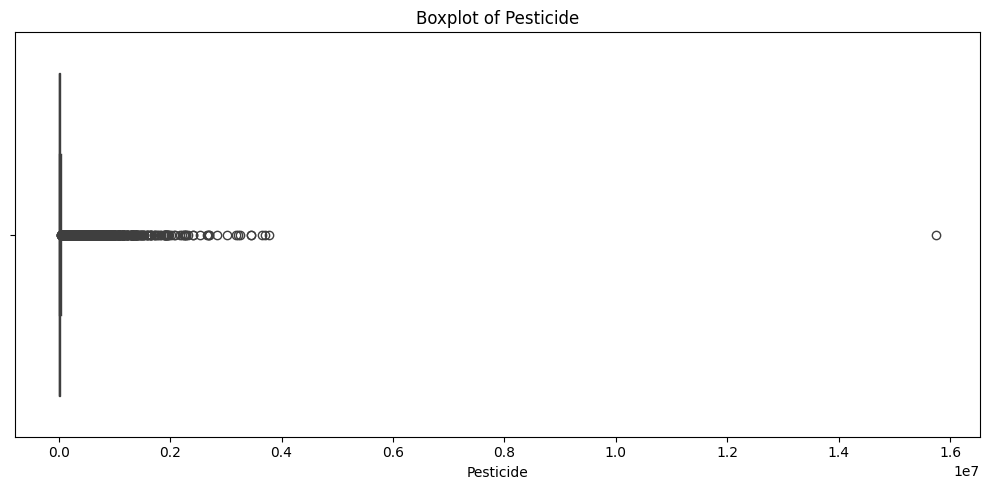

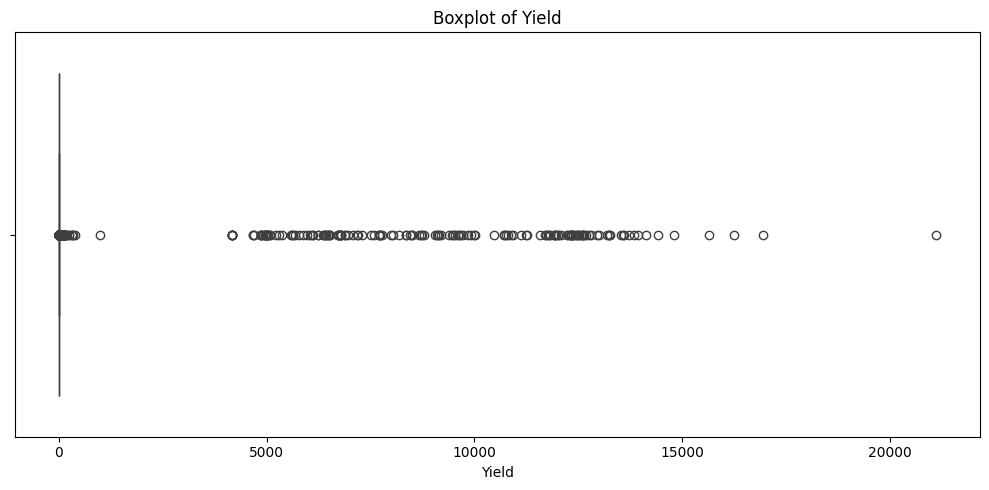

In [7]:
# ==========================================
# OUTLIER VISUALIZATION
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = [
    "Area",
    "Production",
    "Annual_Rainfall",
    "Fertilizer",
    "Pesticide",
    "Yield"
]

for col in numerical_cols:

    plt.figure(figsize=(10, 5))

    sns.boxplot(
        x=yield_df[col]
    )

    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

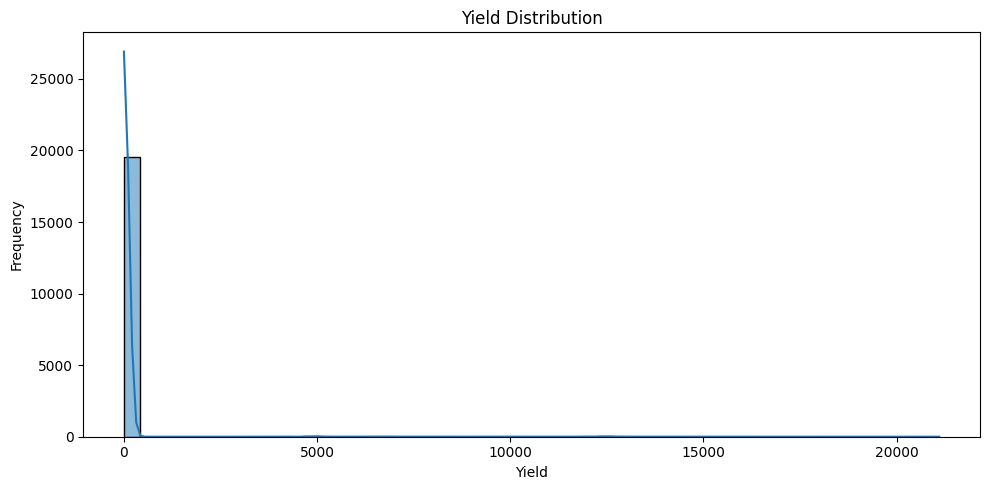

In [8]:
plt.figure(figsize=(10, 5))

sns.histplot(
    yield_df["Yield"],
    bins=50,
    kde=True
)

plt.title("Yield Distribution")
plt.xlabel("Yield")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Features and target
X = yield_df[
    [
        'Crop',
        'Crop_Year',
        'Season',
        'State',
        'Area',
        'Annual_Rainfall',
        'Fertilizer',
        'Pesticide'
    ]
]

y = yield_df['Yield']

# Categorical columns
categorical_features = [
    'Crop',
    'Season',
    'State'
]

# Numerical columns
numerical_features = [
    'Crop_Year',
    'Area',
    'Annual_Rainfall',
    'Fertilizer',
    'Pesticide'
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ],
    remainder='passthrough'
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Fit preprocessing only on training data
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Original training shape:", X_train.shape)
print("Encoded training shape:", X_train_encoded.shape)
print("Original testing shape:", X_test.shape)
print("Encoded testing shape:", X_test_encoded.shape)

Original training shape: (15751, 8)
Encoded training shape: (15751, 96)
Original testing shape: (3938, 8)
Encoded testing shape: (3938, 96)


In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

results = []

for name, model in models.items():

    # Train
    model.fit(X_train_encoded, y_train)

    # Predict
    y_pred = model.predict(X_test_encoded)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

    print(f"\n{name}")
    print("-" * 40)
    print(f"MAE      : {mae:.4f}")
    print(f"RMSE     : {rmse:.4f}")
    print(f"R2 Score : {r2:.4f}")

# Results table
results_df = pd.DataFrame(results)

print("\nModel Comparison")
display(results_df.sort_values(by="R2 Score", ascending=False))


Linear Regression
----------------------------------------
MAE      : 149.8565
RMSE     : 895.0924
R2 Score : 0.0001

Decision Tree
----------------------------------------
MAE      : 11.3316
RMSE     : 178.5371
R2 Score : 0.9602

Random Forest
----------------------------------------
MAE      : 9.3308
RMSE     : 125.8200
R2 Score : 0.9802

Model Comparison


,Model,MAE,RMSE,R2 Score
2,Random Forest,9.330814,125.819996,0.980242
1,Decision Tree,11.331642,178.537094,0.960217
0,Linear Regression,149.856494,895.092365,0.000062


In [13]:
from sklearn.model_selection import cross_validate

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

cv_results = cross_validate(
    rf,
    X_train_encoded,
    y_train,
    cv=5,
    scoring={
        'MAE': 'neg_mean_absolute_error',
        'RMSE': 'neg_root_mean_squared_error',
        'R2': 'r2'
    },
    n_jobs=-1
)

cv_mae = -cv_results['test_MAE']
cv_rmse = -cv_results['test_RMSE']
cv_r2 = cv_results['test_R2']

print("Random Forest - 5 Fold Cross Validation")
print("-" * 45)

print(f"Mean MAE  : {cv_mae.mean():.4f}")
print(f"Std MAE   : {cv_mae.std():.4f}")

print(f"Mean RMSE : {cv_rmse.mean():.4f}")
print(f"Std RMSE  : {cv_rmse.std():.4f}")

print(f"Mean R2   : {cv_r2.mean():.4f}")
print(f"Std R2    : {cv_r2.std():.4f}")

Random Forest - 5 Fold Cross Validation
---------------------------------------------
Mean MAE  : 9.6774
Std MAE   : 1.5868
Mean RMSE : 173.6934
Std RMSE  : 90.2767
Mean R2   : 0.9488
Std R2    : 0.0567


In [14]:
RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

RandomForestRegressor(n_estimators=200, random_state=42)

In [15]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [1.0, "sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_encoded, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation R²:")
print(random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': None}

Best Cross-Validation R²:
0.9486767463273992


In [16]:
# ==========================================
# FINAL TUNED RANDOM FOREST
# ==========================================

best_model = RandomForestRegressor(
    n_estimators=300,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features=1.0,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Train on complete training data
best_model.fit(X_train_encoded, y_train)

# Predict on untouched test data
y_pred_final = best_model.predict(X_test_encoded)

# Evaluation
mae = mean_absolute_error(y_test, y_pred_final)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2 = r2_score(y_test, y_pred_final)

print("Final Tuned Random Forest Performance")
print("-" * 45)
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Final Tuned Random Forest Performance
---------------------------------------------
MAE  : 9.6624
RMSE : 129.6144
R²   : 0.9790


In [17]:
# ==========================================
# FEATURE IMPORTANCE
# ==========================================

feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("Top 20 Important Features:")
display(importance_df.head(20))

Top 20 Important Features:


,Feature,Importance
9,categorical__Crop_Coconut,0.852253
93,remainder__Annual_Rainfall,0.032715
92,remainder__Area,0.019281
95,remainder__Pesticide,0.019098
73,categorical__State_Karnataka,0.018811
94,remainder__Fertilizer,0.014592
90,categorical__State_West Bengal,0.011953
63,categorical__State_Assam,0.010531
91,remainder__Crop_Year,0.006342
65,categorical__State_Chhattisgarh,0.004030


<Figure size 1000x700 with 0 Axes>

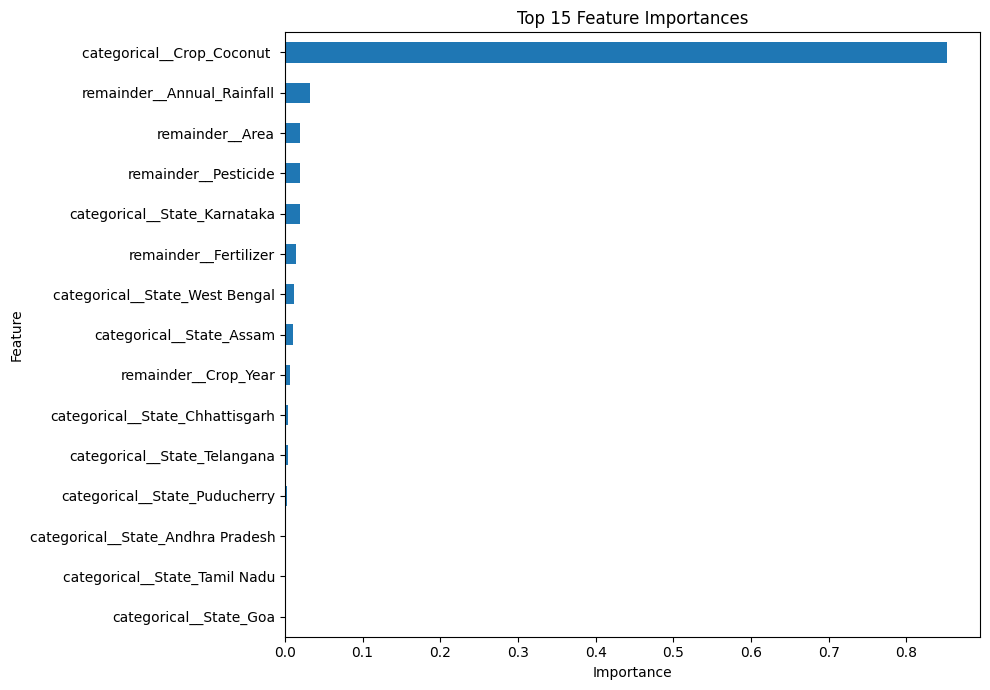

In [18]:
plt.figure(figsize=(10, 7))

importance_df.head(15).sort_values(
    by="Importance"
).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    legend=False,
    figsize=(10, 7)
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [20]:
# Check average yield by crop

crop_yield = yield_df.groupby("Crop")["Yield"].agg(
    ["count", "mean", "median", "std"]
).sort_values("mean", ascending=False)

print(crop_yield)

                       count         mean       median          std
Crop                                                               
Coconut                  172  8652.000199  8466.315523  3772.524093
Sugarcane                605    51.727439    53.158158    30.608713
Banana                   245    26.851128    17.948750    20.428811
Tapioca                  201    16.667301    11.117778    11.329864
Potato                   628    13.331718    10.175284    20.328776
Onion                    454    13.247525     9.192846    23.603768
Sweet potato             273     9.240788     8.512727     5.014707
Jute                     181     7.555393     8.146250     5.019372
Ginger                   323     6.442202     4.887500     6.373005
Mesta                    210     5.389204     4.935250     3.407972
Garlic                   250     4.544886     3.306807     3.875642
Maize                    975     3.427216     1.955455    31.688399
Turmeric                 337     3.325392     2.

In [22]:
# Check yield specifically for Coconut

print(yield_df[yield_df["Crop"] == "Coconut"]["Yield"].describe())

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Yield, dtype: float64


In [24]:
# Compare Coconut with all other crops

print("Coconut mean yield:",
      yield_df[yield_df["Crop"] == "Coconut"]["Yield"].mean())

print("Other crops mean yield:",
      yield_df[yield_df["Crop"] != "Coconut"]["Yield"].mean())

Coconut mean yield: nan
Other crops mean yield: 79.95400913008669


In [26]:
print(yield_df["Crop"].unique()[:20])

print("\nCoconut-related values:")
print(yield_df[yield_df["Crop"].astype(str).str.contains("Coconut", case=False, na=False)]["Crop"].unique())

['Arecanut' 'Arhar/Tur' 'Castor seed' 'Coconut ' 'Cotton(lint)'
 'Dry chillies' 'Gram' 'Jute' 'Linseed' 'Maize' 'Mesta' 'Niger seed'
 'Onion' 'Other  Rabi pulses' 'Potato' 'Rapeseed &Mustard' 'Rice'
 'Sesamum' 'Small millets' 'Sugarcane']

Coconut-related values:
['Coconut ']


In [28]:
# Clean Crop names
yield_df["Crop"] = yield_df["Crop"].astype(str).str.strip()

# Check Coconut
coconut_data = yield_df[yield_df["Crop"].str.lower() == "coconut"]

print(coconut_data["Yield"].describe())

print("\nCoconut count:", len(coconut_data))
print("Coconut mean yield:", coconut_data["Yield"].mean())

other_data = yield_df[yield_df["Crop"].str.lower() != "coconut"]

print("Other crops mean yield:", other_data["Yield"].mean())

count      172.000000
mean      8652.000199
std       3772.524093
min          0.000000
25%       5947.844286
50%       8466.315523
75%      11982.216875
max      21105.000000
Name: Yield, dtype: float64

Coconut count: 172
Coconut mean yield: 8652.000198744186
Other crops mean yield: 4.410024674810525


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Predictions from final tuned model
y_pred = best_model.predict(X_test_encoded)

# Create evaluation dataframe
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Crop": yield_df.loc[y_test.index, "Crop"].values
})

# Evaluate each crop
crop_results = []

for crop in results["Crop"].unique():

    crop_data = results[results["Crop"] == crop]

    mae = mean_absolute_error(
        crop_data["Actual"],
        crop_data["Predicted"]
    )

    rmse = np.sqrt(
        mean_squared_error(
            crop_data["Actual"],
            crop_data["Predicted"]
        )
    )

    r2 = r2_score(
        crop_data["Actual"],
        crop_data["Predicted"]
    ) if len(crop_data) > 1 else np.nan

    crop_results.append({
        "Crop": crop,
        "Count": len(crop_data),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

crop_results_df = pd.DataFrame(crop_results)

crop_results_df = crop_results_df.sort_values(
    "R2",
    ascending=False
)

print(crop_results_df.to_string(index=False))

                 Crop  Count         MAE        RMSE          R2
               Garlic     31    0.520352    0.774387    0.965470
            Sugarcane    112    5.820902    8.148831    0.923059
       other oilseeds     27    0.415047    0.906513    0.915566
              Tapioca     34    2.093055    3.374522    0.911132
Peas & beans (Pulses)     88    0.234474    0.559090    0.901546
              Coconut     34 1026.994339 1394.418318    0.891838
               Barley     52    0.227415    0.313874    0.888634
             Arecanut     37    0.452841    0.839932    0.885746
             Turmeric     61    0.519789    1.141875    0.880448
   Other  Rabi pulses     76    0.124381    0.175912    0.879953
                 Ragi     98    0.156516    0.216849    0.870132
                 Jute     35    1.394481    2.080978    0.869490
                Wheat    103    0.299527    0.467220    0.867467
                Bajra     99    0.776832    3.997480    0.791164
            Groundnut    

In [32]:
# Show the 10 worst performing crops

worst_crops = crop_results_df.sort_values("R2").head(10)

print(worst_crops.to_string(index=False))

               Crop  Count      MAE     RMSE          R2
          Cashewnut     27 3.896347 9.480221 -767.797597
       Dry chillies     89 1.100936 6.102079  -18.858526
              Jowar    102 0.351452 1.695988  -10.025871
              Maize    197 1.017651 7.241079   -8.903055
          Guar seed     13 0.292990 0.454464   -4.876531
               Rice    236 0.367447 1.835065   -2.873859
Other Summer Pulses      5 1.118984 1.524622   -2.074932
      Other Cereals     28 0.365947 0.488426   -0.330431
       Cotton(lint)     98 0.651099 1.263239   -0.183272
           Cardamom     17 0.210910 0.632427    0.080737


In [34]:
# Check actual yield statistics for the worst crops

worst_crop_names = worst_crops["Crop"].tolist()

print(
    yield_df[yield_df["Crop"].isin(worst_crop_names)]
    .groupby("Crop")["Yield"]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .sort_values("std")
    .to_string()
)

                     count      mean        std       min    median         max
Crop                                                                           
Cardamom                74  0.168355   0.376737  0.000000  0.076778    2.870000
Jowar                  513  1.072498   0.518530  0.003571  0.979524    3.579091
Other Cereals          146  0.849546   0.532084  0.095455  0.778558    4.394000
Other Summer Pulses     10  0.859925   0.709807  0.334667  0.679375    2.800000
Rice                  1197  2.218495   0.802459  0.016667  2.203636    8.778276
Guar seed               63  0.951875   1.296764  0.000000  0.812419   10.651481
Dry chillies           419  2.078330   2.416577  0.205000  1.012857   14.000000
Cotton(lint)           476  1.797044   4.459462  0.000000  1.428365   95.993913
Cashewnut              134  3.120438  29.197475  0.000000  0.462500  338.548966
Maize                  975  3.427216  31.688399  0.000000  1.955455  989.870000


In [36]:
print("Yield Skewness:", yield_df["Yield"].skew())

Yield Skewness: 12.785264685628691


In [37]:
# ==========================================
# RANDOM FOREST WITH LOG-TRANSFORMED TARGET
# ==========================================

import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Log transform the target
y_train_log = np.log1p(y_train)

# Create model
log_rf = RandomForestRegressor(
    n_estimators=300,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features=1.0,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Train using log-transformed target
log_rf.fit(X_train_encoded, y_train_log)

# Predict in log scale
y_pred_log = log_rf.predict(X_test_encoded)

# Convert predictions back to original Yield scale
y_pred_log_original = np.expm1(y_pred_log)

# Evaluate on original Yield scale
log_mae = mean_absolute_error(y_test, y_pred_log_original)
log_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_log_original)
)
log_r2 = r2_score(y_test, y_pred_log_original)

print("Random Forest with Log-Transformed Target")
print("-" * 50)
print(f"MAE  : {log_mae:.4f}")
print(f"RMSE : {log_rmse:.4f}")
print(f"R²   : {log_r2:.4f}")


Random Forest with Log-Transformed Target
--------------------------------------------------
MAE  : 13.2446
RMSE : 277.8645
R²   : 0.9036


In [38]:
# ==========================================
# RESIDUAL / ERROR ANALYSIS
# ==========================================

residuals = y_test - y_pred_final

print("Residual Statistics")
print("-" * 40)
print(f"Mean Residual : {residuals.mean():.4f}")
print(f"Std Residual  : {residuals.std():.4f}")
print(f"Min Residual  : {residuals.min():.4f}")
print(f"Max Residual  : {residuals.max():.4f}")

Residual Statistics
----------------------------------------
Mean Residual : 2.3748
Std Residual  : 129.6091
Min Residual  : -3176.0428
Max Residual  : 4037.3105


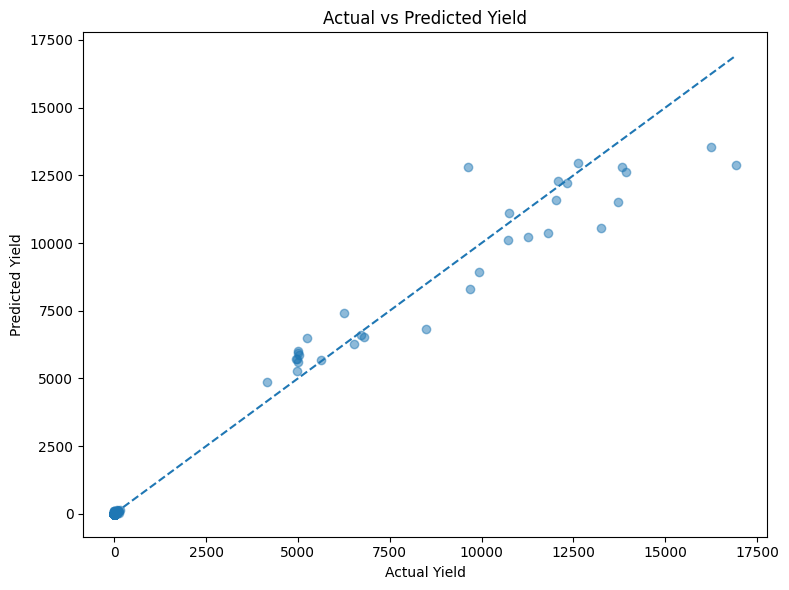

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_final, alpha=0.5)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield")

# Perfect prediction line
min_value = min(y_test.min(), y_pred_final.min())
max_value = max(y_test.max(), y_pred_final.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.tight_layout()
plt.show()

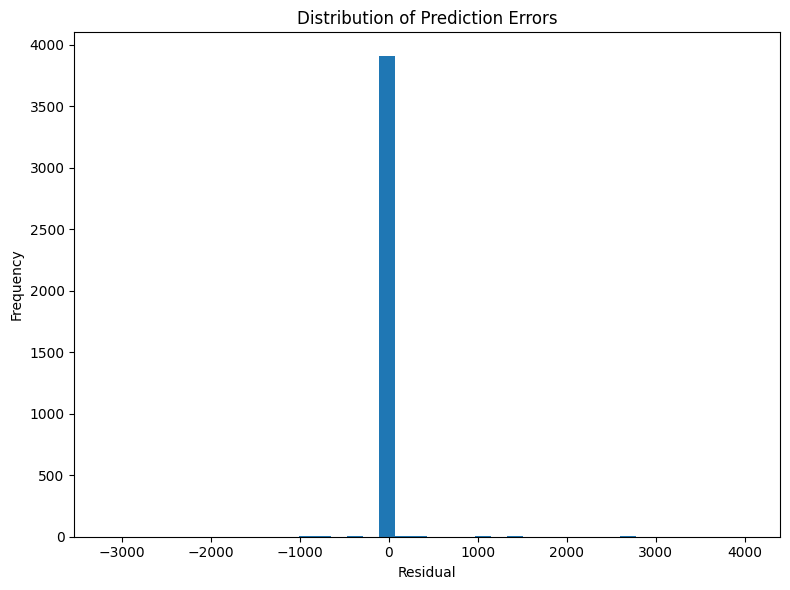

In [40]:
plt.figure(figsize=(8, 6))

plt.hist(residuals, bins=40)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.tight_layout()
plt.show()

In [41]:
# ==========================================
# FINAL YIELD MODEL
# ==========================================

import joblib
from sklearn.ensemble import RandomForestRegressor

# Final tuned Random Forest
final_rf = RandomForestRegressor(
    n_estimators=300,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features=1.0,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Train on original Yield target
final_rf.fit(X_train_encoded, y_train)

# Save model
joblib.dump(
    final_rf,
    "yield_random_forest_model.pkl"
)

print("Final Yield Random Forest trained and saved successfully!")

Final Yield Random Forest trained and saved successfully!


In [42]:
import os

print(os.path.exists("yield_random_forest_model.pkl"))

True


In [43]:
print(type(preprocessor))


<class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [45]:
import joblib

joblib.dump(
    preprocessor,
    "yield_preprocessor.pkl"
)

print("Preprocessor saved successfully!")

Preprocessor saved successfully!


In [46]:
import os

print("Model:", os.path.exists("yield_random_forest_model.pkl"))
print("Preprocessor:", os.path.exists("yield_preprocessor.pkl"))

Model: True
Preprocessor: True
